In [3]:
import sys
import os
import re
from PIL import Image

In [4]:
# Unicode range for Devanagari block
DEVANAGARI_RE = re.compile(r'[\u0900-\u097F]')

In [5]:
def is_hindi(word: str) -> bool:
    """Return True if the word contains any Devanagari character."""
    return bool(DEVANAGARI_RE.search(word))

def find_image(filepath_base, parent_dir):
    """Try common extensions to find the matching image file."""
    for ext in (".png", ".jpg", ".jpeg", ".tif", ".tiff"):
        p = os.path.join(parent_dir, filepath_base + ext)
        if os.path.exists(p):
            return p
    return None

In [25]:
def main(root_dir, out_crops_dir, max_crops=1_000_000):
    os.makedirs(out_crops_dir, exist_ok=True)
    ann_file = os.path.join(out_crops_dir,"../", "annotations.txt")
    crop_count = 0

    with open(ann_file, "w", encoding="utf8") as ann:
        for dirpath, dirnames, filenames in os.walk(root_dir):
            if crop_count >= max_crops:
                break
            if os.path.basename(dirpath) != "out":
                continue

            parent = os.path.dirname(dirpath)
            dir_name = os.path.basename(parent)

            for fn in filenames:
                if crop_count >= max_crops:
                    break
                if not fn.lower().endswith(".box"):
                    continue

                box_path = os.path.join(dirpath, fn)
                base = os.path.splitext(fn)[0]
                img_path = find_image(base, parent)
                if img_path is None:
                    print(f"[WARN] no image for {box_path}", file=sys.stderr)
                    continue

                img = Image.open(img_path)
                with open(box_path, encoding="utf8") as f:
                    for line in f:
                        if crop_count >= max_crops:
                            break

                        line = line.strip()
                        if not line:
                            continue

                        parts = line.split("\t")
                        
                        if len(parts) != 2:
                            # print(">>>>", parts)
                            # print(f"[WARN] bad format in {box_path}: '{line}'", file=sys.stderr)
                            continue

                        coords, word = parts
                        if not is_hindi(word):
                            continue

                        try:
                            x1, y1, x2, y2 = map(int, coords.split())
                        except ValueError:
                            print(f"[WARN] bad coords '{coords}' in {box_path}", file=sys.stderr)
                            continue

                        crop = img.crop((x1, y1, x2, y2))
                        out_name = f"{dir_name}_{x1}_{y1}_{x2}_{y2}.png"
                        out_path = os.path.join(out_crops_dir, out_name)
                        crop.save(out_path)

                        ann.write(f"{out_path}\t{word}\n")
                        crop_count += 1

                        if crop_count %1000 ==0:
                            print(f"Reached {crop_count} crop words")


    print(f"Done. Generated {crop_count} crops (limit was {max_crops}).")
    print("Crops are in:", out_crops_dir)
    print("Annotations file:", ann_file)

In [26]:
if __name__ == "__main__":
    root_dir = "/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/1970s"
    out_dir = "/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/all_crop_words"
    main(root_dir, out_dir)

Reached 1000 crop words
Reached 2000 crop words
Reached 3000 crop words
Reached 4000 crop words
Reached 5000 crop words
Reached 6000 crop words
Reached 7000 crop words
Reached 8000 crop words
Reached 9000 crop words
Reached 10000 crop words
Reached 11000 crop words
Reached 12000 crop words
Reached 13000 crop words
Reached 14000 crop words
Reached 15000 crop words
Reached 16000 crop words
Reached 17000 crop words
Reached 18000 crop words
Reached 19000 crop words
Reached 20000 crop words
Reached 21000 crop words
Reached 22000 crop words
Reached 23000 crop words
Reached 24000 crop words
Reached 25000 crop words
Reached 26000 crop words
Reached 27000 crop words
Reached 28000 crop words
Reached 29000 crop words
Reached 30000 crop words
Reached 31000 crop words
Reached 32000 crop words
Reached 33000 crop words
Reached 34000 crop words
Reached 35000 crop words
Reached 36000 crop words
Reached 37000 crop words
Reached 38000 crop words
Reached 39000 crop words
Reached 40000 crop words
Reached 4

---
---

### Sample and move

In [28]:
#!/usr/bin/env python3
import os
import sys
import random
import shutil

def main(ann_path, out_dir, sample_size, seed=42):
    # 1) Read all lines
    with open(ann_path, encoding="utf8") as f:
        lines = [l.rstrip("\n") for l in f if l.strip()]

    total = len(lines)
    if sample_size > total:
        print(f"[ERROR] sample_size {sample_size} > total lines {total}")
        sys.exit(1)

    # 2) Sample
    random.seed(seed)
    sampled = random.sample(lines, sample_size)

    # 3) Prepare output dir
    os.makedirs(out_dir, exist_ok=True)

    # 4) Move files & write new annotations
    out_ann_path = os.path.join(out_dir, "unvarified_annotation_val.txt")
    with open(out_ann_path, "w", encoding="utf8") as out_f:
        for entry in sampled:
            img_path, word = entry.split("\t", 1)
            if not os.path.exists(img_path):
                print(f"[WARN] image not found: {img_path}", file=sys.stderr)
                continue

            # move the image
            fname = os.path.basename(img_path)
            new_img_path = os.path.join(out_dir, fname)
            shutil.move(img_path, new_img_path)

            # write to new annotation
            out_f.write(f"{new_img_path}\t{word}\n")

    print(f"Sampled {sample_size} of {total} lines.")
    print("Images moved into:", out_dir)
    print("New annotation file:", out_ann_path)


if __name__ == "__main__":

    ann_file = "/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/annotations.txt"
    k = 6000
    output_dir = f"/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/unvarified_{k}_val"
    
    sd = 42

    main(ann_file, output_dir, k, sd)


Sampled 6000 of 1000000 lines.
Images moved into: /home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/unvarified_6000_val
New annotation file: /home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/unvarified_6000_val/unvarified_annotation_val.txt


---
---

## Making compatible for SSL

In [1]:
import os
import random
import shutil
from pathlib import Path

In [ ]:
# input_txt = Path("/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/annotations.txt")

# # Directory to copy the 80% images into
# holdout_dir = Path("holdout_images")
# holdout_dir.mkdir(exist_ok=True, parents=True)

In [ ]:
# # Output files for the 20% sample
# train_images_txt = Path("train_images.txt")
# labels_txt       = Path("train_labels.txt")

# # Fraction to select for the train/label split
# train_frac = 0.2

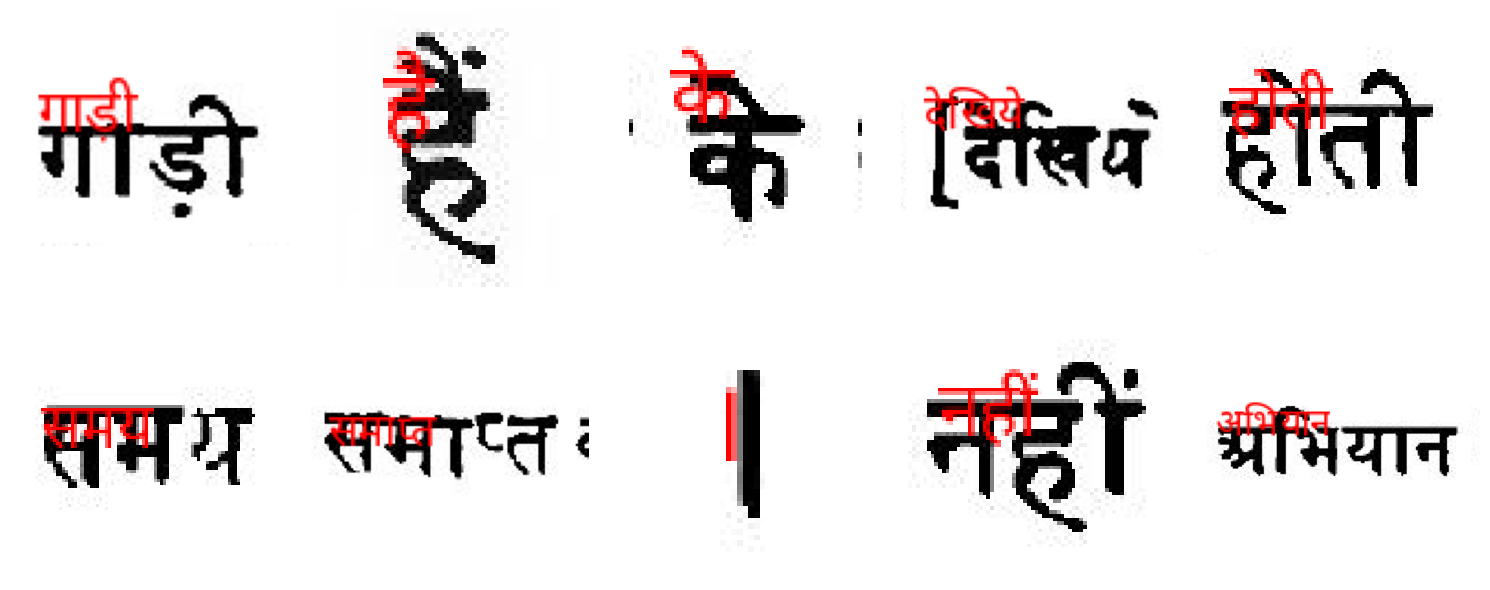

In [ ]:
# import random
# from pathlib import Path
# from PIL import Image, ImageDraw, ImageFont
# import matplotlib.pyplot as plt
# import math

# # 1. Read all lines
# with input_txt.open("r", encoding="utf-8") as f:
#     lines = [line.rstrip("\n") for line in f if line.strip()]



# # 2. Compute how many to sample
# total = len(lines)
# k = max(1, int(total * train_frac))

# # 3. Randomly sample indices, then sort to preserve original order
# all_indices = list(range(total))
# train_indices = sorted(random.sample(all_indices, k))
# print(">>>>, creating hold out indices")
# holdout_indices = [i for i in all_indices if i not in train_indices]
# print(">>>created holdeout indices")
# # 4. Write out train_images.txt and labels.txt
# with train_images_txt.open("w", encoding="utf-8") as fi, \
#      labels_txt.open("w", encoding="utf-8") as fl:
#     for idx in train_indices:
#         img_path, label = lines[idx].split("\t", 1)
#         fi.write(f"{img_path}\n")
#         fl.write(f"{label}\n")

# print(f"Wrote {k} entries to {train_images_txt.name} and {labels_txt.name}.")

# # 5. Copy the other 80% of images to the holdout dir
# for idx in holdout_indices:
#     img_path, _ = lines[idx].split("\t", 1)
#     src = Path(img_path)
#     dst = holdout_dir / src.relative_to(src.parents[4])  # Change 4 if needed to get relative path inside holdout
#     dst.parent.mkdir(parents=True, exist_ok=True)
#     try:
#         shutil.copy(src, dst)
#     except FileNotFoundError:
#         print(f"Warning: {src} not found, skipping.")

# print(f"Copied {len(holdout_indices)} images to '{holdout_dir}/'.")

In [ ]:
# ##Utils
# # 2. Sample up to 10 random lines
# sample_lines = random.sample(lines, min(10, len(lines)))

# # 3. Load images, draw labels
# annotated_images = []
# for line in sample_lines:
#     img_path, label = line.split("\t", 1)
#     img = Image.open(img_path)
#     draw = ImageDraw.Draw(img)
#     try:
#         font = ImageFont.truetype("/home/akash/ws/limited_supervision_ocr/data_hi/book_1246_ajoy_style_gt/resources/NotoSansDevanagari-Regular.ttf", size=20)
#     except IOError:
#         font = ImageFont.load_default()
#     # Draw label at top-left
#     draw.text((10, 10), label, font=font, fill= "red")
#     annotated_images.append(img)

# # 4. Display in a grid
# cols = 5
# rows = math.ceil(len(annotated_images) / cols)
# fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

# for ax in axes.flatten():
#     ax.axis('off')

# for ax, img in zip(axes.flatten(), annotated_images):
#     ax.imshow(img)

# plt.tight_layout()
# plt.show()

In [ ]:
import shutil
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def interactive_filter(
    images_txt: Path,
    labels_txt: Path,
    output_images_txt: Path,
    output_labels_txt: Path,
    delete_discarded: bool = False,
    font_path: Path = Path("/home/akash/ws/limited_supervision_ocr/data_hi/book_1246_ajoy_style_gt/resources/NotoSansDevanagari-Regular.ttf"),
    font_size: int = 24
):
    """
    Interactively displays images with their annotations and allows
    the user to keep or discard each pair.

    Args:
        images_txt: Path to file listing image paths, one per line.
        labels_txt: Path to file listing labels/text, one per line.
        output_images_txt: Path to write filtered image paths.
        output_labels_txt: Path to write filtered labels.
        delete_discarded: If True, delete discarded image files.
        font_path: Path to a .ttf font file for rendering text.
        font_size: Size of the annotation text.
    """
    # Read image paths and labels
    with images_txt.open("r", encoding="utf-8") as fi:
        image_paths = [line.strip() for line in fi if line.strip()]
    with labels_txt.open("r", encoding="utf-8") as fl:
        labels = [line.strip() for line in fl if line.strip()]

    if len(image_paths) != len(labels):
        raise ValueError(
            f"Number of images ({len(image_paths)}) and labels ({len(labels)}) must match."
        )

    # Load custom font
    try:
        font = ImageFont.truetype(str(font_path), font_size)
    except Exception:
        font = ImageFont.load_default()

    kept_images: list[str] = []
    kept_labels: list[str] = []

    total = len(image_paths)
    for idx, (img_path, label) in enumerate(zip(image_paths, labels), start=1):
        src = Path(img_path)
        if not src.exists():
            print(f"[Warning] {src} not found, skipping.")
            continue

        # Open image and draw annotation text
        img = Image.open(src).convert("RGB")
        draw = ImageDraw.Draw(img)
        margin = 10
        # Wrap text if too long
        lines = []
        words = label.split()
        current_line = ""
        for word in words:
            test = f"{current_line} {word}".strip()
            w, h = draw.textsize(test, font=font)
            if w + 2*margin > img.width:
                lines.append(current_line)
                current_line = word
            else:
                current_line = test
        lines.append(current_line)

        # Calculate total text block height
        text_height = sum(draw.textsize(line, font=font)[1] for line in lines)
        y_text = margin
        # Semi-transparent overlay
        overlay = Image.new('RGBA', img.size, (0,0,0,0))
        od = ImageDraw.Draw(overlay)
        box_height = text_height + (len(lines)+1)*margin/2
        od.rectangle([margin, margin, img.width-margin, margin+box_height], fill=(0,0,0,160))
        img = Image.alpha_composite(img.convert('RGBA'), overlay)
        draw = ImageDraw.Draw(img)

        for line in lines:
            draw.text((margin, y_text), line, font=font, fill=(255,255,255))
            y_text += draw.textsize(line, font=font)[1] + margin/2

        # Display annotated image
        plt.figure(figsize=(8, 6))
        plt.imshow(img.convert('RGB'))
        plt.axis('off')
        plt.show()

        # Prompt user
        resp = input(f"[{idx}/{total}] Keep this image and annotation? [y/N]: ").strip().lower()
        if resp == 'y':
            kept_images.append(img_path)
            kept_labels.append(label)
        else:
            print(f"Discarding {src.name}...")
            if delete_discarded:
                try:
                    src.unlink()
                except Exception as e:
                    print(f"Could not delete {src}: {e}")

    # Write kept entries
    with output_images_txt.open("w", encoding="utf-8") as fi, \
         output_labels_txt.open("w", encoding="utf-8") as fl:
        for img_path in kept_images:
            fi.write(f"{img_path}\n")
        for label in kept_labels:
            fl.write(f"{label}\n")

    print(f"Completed. Kept {len(kept_images)} of {total} entries.")


# Specify file paths here:
if __name__ == '__main__':
    images_txt = Path("/home/akash/ws/limited_supervision_ocr/data_hi/train_images.txt")
    labels_txt = Path("/home/akash/ws/limited_supervision_ocr/data_hi/train_labels.txt")
    output_images_txt = Path("/home/akash/ws/limited_supervision_ocr/data_hi/corrected_train_images.txt")
    output_labels_txt = Path("/home/akash/ws/limited_supervision_ocr/data_hi/corrected_train_labels.txt")
    # Call function without argparse
    interactive_filter(
        images_txt,
        labels_txt,
        output_images_txt,
        output_labels_txt,
        delete_discarded=False,
        font_path=Path("/home/akash/ws/limited_supervision_ocr/data_hi/book_1246_ajoy_style_gt/resources/NotoSansDevanagari-Regular.ttf"),
        font_size=24
    )


In [ ]:
# split_dataset.py

import random
import shutil
from pathlib import Path
from PIL import Image, UnidentifiedImageError

# Configuration
input_txt = Path("/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/annotations.txt") #Path("input.txt")         # Path to the input file (image_path<TAB>label per line)
train_frac = 0.002                       # Fraction of data to use for training ##2k word images
output_dir = Path("train_holdeout_images_labels")  # Directory where outputs will be saved
holdout_dir = output_dir / "holdout"  # Directory to copy holdout images

# Derived output files
output_dir.mkdir(parents=True, exist_ok=True)
train_images_txt = output_dir / "train_images.txt"
train_labels_txt = output_dir / "train_labels.txt"
holdout_images_txt = output_dir / "holdout_images.txt"
holdout_labels_txt = output_dir / "holdout_labels.txt"

# Helper to check if an image file is valid
def is_valid_image(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()  # verify that it is, in fact an image
        return True
    except (FileNotFoundError, UnidentifiedImageError, OSError) as e:
        print(f"Warning: Invalid image {path!r} ({e}), skipping.")
        return False

# 1. Read all non-empty lines and strip newline
with input_txt.open("r", encoding="utf-8") as f:
    lines = [line.rstrip("\n") for line in f if line.strip()]

# 2. Split into image paths and labels, preserving order
pairs = [line.split("\t", 1) for line in lines]
total = len(pairs)
# Always keep at least one training example
k = max(1, int(total * train_frac))

# 3. Randomly sample indices for train set, then sort to preserve original order
all_indices = list(range(total))
train_indices = sorted(random.sample(all_indices, k))
holdout_indices = [i for i in all_indices if i not in train_indices]

print(f"Creating train set with ~{len(train_indices)} entries (valid only) and holdout with ~{len(holdout_indices)} entries (valid only).")

# 4. Write train lists, preserving alignment: only valid images
with train_images_txt.open("w", encoding="utf-8") as fi, \
     train_labels_txt.open("w", encoding="utf-8") as fl:
    for idx in train_indices:
        img_path_str, label = pairs[idx]
        img_path = Path(img_path_str)
        if is_valid_image(img_path):
            fi.write(f"{img_path}\n")
            fl.write(f"{label}\n")

# 5. Write holdout lists, preserving alignment: only valid images
with holdout_images_txt.open("w", encoding="utf-8") as fi, \
     holdout_labels_txt.open("w", encoding="utf-8") as fl:
    for idx in holdout_indices:
        img_path_str, label = pairs[idx]
        img_path = Path(img_path_str)
        if is_valid_image(img_path):
            fi.write(f"{img_path}\n")
            fl.write(f"{label}\n")

# 6. Copy holdout images to holdout directory, preserving relative structure for valid ones
for idx in holdout_indices:
    img_path_str, _ = pairs[idx]
    src = Path(img_path_str)
    if not is_valid_image(src):
        continue
    try:
        rel = src.relative_to(src.parents[4])
    except ValueError:
        rel = src.name
    dst = holdout_dir / rel
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        shutil.copy(src, dst)
    except (FileNotFoundError, OSError) as e:
        print(f"Warning: Failed to copy {src!r} ({e}), skipping.")

print(f"Wrote valid train lists: {train_images_txt.name}, {train_labels_txt.name}")
print(f"Wrote valid holdout lists: {holdout_images_txt.name}, {holdout_labels_txt.name}")
print(f"Copied valid images to '{holdout_dir}")

/tmp/ipykernel_2618282/2715857437.py:45: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_size = draw.textsize(label, font=font)
/tmp/ipykernel_2618282/2715857437.py:45: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_size = draw.textsize(label, font=font)
/tmp/ipykernel_2618282/2715857437.py:45: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_size = draw.textsize(label, font=font)
/tmp/ipykernel_2618282/2715857437.py:45: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_size = draw.textsize(label, font=font)
/tmp/ipykernel_2618282/2715857437.py:45: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or t

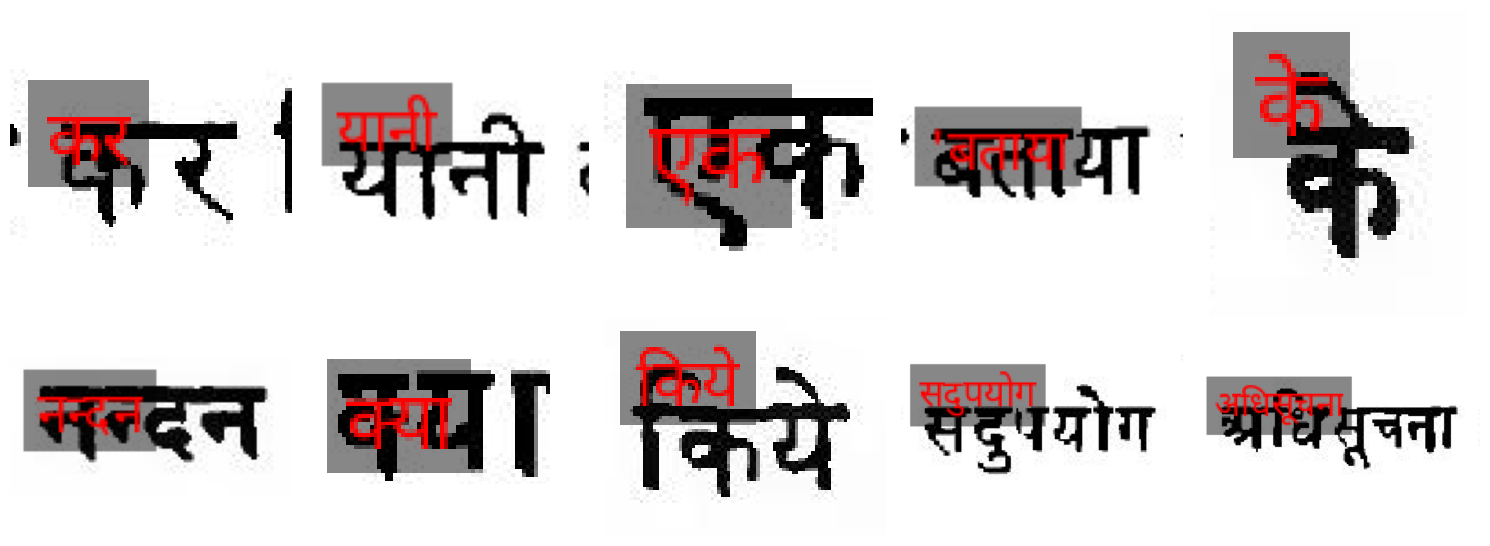

In [21]:
import random
import math
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# Paths to the train files
train_images_txt = Path("/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/train_holdeout_images_labels/train_images.txt")
train_labels_txt = Path("/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/train_holdeout_images_labels/train_labels.txt")

# Read the lines
with train_images_txt.open("r", encoding="utf-8") as fi, \
     train_labels_txt.open("r", encoding="utf-8") as fl:
    image_paths = [line.strip() for line in fi if line.strip()]
    labels = [line.strip() for line in fl if line.strip()]

# Pair and sample up to 10
pairs = list(zip(image_paths, labels))
sample_pairs = random.sample(pairs, min(10, len(pairs)))

# Annotate images
annotated_images = []
for img_path, label in sample_pairs:
    try:
        img = Image.open(img_path).convert("RGB")
    except Exception as e:
        # Create blank image on error
        img = Image.new("RGB", (200, 200), color=(255, 255, 255))
        draw = ImageDraw.Draw(img)
        draw.text((10, 90), "Load Error", fill="red")
        annotated_images.append(img)
        continue

    draw = ImageDraw.Draw(img)
    # Try loading Devanagari-capable font, fallback to default
    try:
        font = ImageFont.truetype(
            "/home/akash/ws/limited_supervision_ocr/data_hi/book_1246_ajoy_style_gt/resources/NotoSansDevanagari-Regular.ttf",
            size=20
        )
    except IOError:
        font = ImageFont.load_default()

    # Draw semi-transparent background for text
    text_size = draw.textsize(label, font=font)
    background = Image.new("RGBA", (text_size[0] + 10, text_size[1] + 10), (0, 0, 0, 120))
    img.paste(background, (5, 5), background)
    
    # Draw the label
    draw.text((10, 10), label, font=font, fill="red")
    annotated_images.append(img)

# Display in a grid
cols = 5
rows = math.ceil(len(annotated_images) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

for ax in axes.flatten():
    ax.axis('off')

for ax, img in zip(axes.flatten(), annotated_images):
    ax.imshow(img)

plt.tight_layout()
plt.show()


---
---

### Create validation LMDB

In [6]:
import os
import sys
import lmdb 
import cv2
import numpy as np
import argparse

def checkImageIsValid(imageBin):
    if imageBin is None:
        print("empty imageBin")
        return False
    imageBuf = np.frombuffer(imageBin, dtype=np.uint8)
    length1 = len(imageBuf)
    if length1 > 0:
        img = cv2.imdecode(imageBuf, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return False
        imgH, imgW = img.shape[0], img.shape[1]
        if imgH * imgW == 0:
            return False
    else:
        return False
    return True

def writeCache(env, cache):
    with env.begin(write=True) as txn:
        for k, v in cache.items():
            if isinstance(v, bytes):
                txn.put(k.encode(), v)
            else:
                txn.put(k.encode(), v.encode())

def createDataset(outputPath, input_file, parentDirofImages, checkValid=True, size=1.0):
    # Read input file and parse lines
    with open(input_file, 'r', encoding='utf-8') as f:
        lines = f.read().strip().splitlines()
    
    imagePathList = []
    labelnameList = []
    for line in lines:
        parts = line.strip().split('\t', 1)  # Split on first tab
        if len(parts) != 2:
            print(f"Skipping invalid line: {line}")
            continue
        img_path, label = parts
        imagePathList.append(img_path)
        labelnameList.append(label.strip())
    
    nSamples = int(len(imagePathList) * size)
    print(f"Total samples to process: {nSamples}")
    assert len(imagePathList) == len(labelnameList), "Mismatch between image paths and labels"
    
    env = lmdb.open(outputPath, map_size=1099511627776)
    cache = {}
    cnt = 1
    
    for i in range(nSamples):
        imagePath = os.path.join(parentDirofImages, imagePathList[i])
        label = labelnameList[i]
        
        if not os.path.exists(imagePath):
            print(f'{imagePath} does not exist')
            continue
        
        with open(imagePath, 'rb') as f:
            imageBin = f.read()
        
        if checkValid and not checkImageIsValid(imageBin):
            print(f'{imagePath} is not a valid image')
            continue
        
        imageKey = f'image-{cnt:09d}'
        labelKey = f'label-{cnt:09d}'
        cache[imageKey] = imageBin
        cache[labelKey] = label
        
        if cnt % 50000 == 0:
            writeCache(env, cache)
            cache = {}
            print(f'Written {cnt} / {nSamples}')
        
        cnt += 1
    
    # Write remaining entries
    if cache:
        writeCache(env, cache)
    
    # Add num-samples to the database
    nSamples = cnt - 1
    with env.begin(write=True) as txn:
        txn.put('num-samples'.encode(), str(nSamples).encode())
    
    print(f'Created dataset with {nSamples} samples')
    return nSamples

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument('--input_file', required=True, help='Path to the input txt file (image paths and labels separated by tab)')
    parser.add_argument('--output_path', required=True, help='Output directory for LMDB database')
    parser.add_argument('--parent_dir', default='', help='Parent directory for image paths (prepended to each image path)')
    parser.add_argument('--size', type=float, default=1.0, help='Fraction of the dataset to use (0.0 to 1.0)')
    
    sys.argv = [
    "notebook",      # dummy program name
    "--input_file", "/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/unvarified_annotation_val.txt",    # sets args.foo = 7
    "--output_path", "/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/lmdbs/validation" # sets args.bar = "hello"
]
    args = parser.parse_args()

    # Create output directory if it doesn't exist
    if not os.path.exists(args.output_path):
        os.makedirs(args.output_path)
    
    createDataset(
        outputPath=args.output_path,
        input_file=args.input_file,
        parentDirofImages=args.parent_dir,
        size=args.size
    )

Total samples to process: 6000
Created dataset with 6000 samples


---
---

In [1]:
with open("/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/train_holdeout_images_labels/train_images.txt", "r", encoding="utf-8") as images_file,\
    open("/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/train_holdeout_images_labels/train_labels.txt", "r", encoding="utf-8") as labels_file, \
    open("/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/train_holdeout_images_labels/train_merged.txt", "w", encoding="utf-8") as output_file:
    # Use zip to iterate over lines from both files in parallel
    for image_line, label_line in zip(images_file, labels_file):
        # Remove any extra whitespace/newline characters
        image_line = image_line.strip()
        label_line = label_line.strip()

        # Write to the output file.
        # You may want both on the same line separated by a delimiter
        # (for example, a tab or a space) or on consecutive lines.
        # Option 1: Append both on one line separated by a tab.
        output_file.write(image_line + "\t" + label_line + "\n")
        
        # Option 2: Write the image line followed by the label on the next line.
        # Uncomment the following lines to use this option.
        # output_file.write(image_line + "\n")
        # output_file.write(label_line + "\n")

### Dataset Statistics
- Word length
- Unique characters
- Level of degradation and types
    - Fading
    - Dislocation
    - Bleed-through
    - Foxing(Reddish Brown spots)
    - Abrasion(Friction scraps away characters)
    - Cockling(wringking duw to water damage)

    - Bluring
    - Noise or artifacts
    - Watermarking
    - Background
    - Encoding corruption
    - File damage


#### Character level analysis

In [ ]:
import sys
import csv
import matplotlib.pyplot as plt


def main(input_file):
    # Initialize statistics trackers
    total_images = 0
    total_words = 0
    total_chars = 0
    all_chars = set()
    per_image_stats = []
    word_lengths_all = []  # For histogram of word lengths

    # Read input file
    with open(input_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t', 1)
            if len(parts) < 2:
                continue  # Skip malformed lines

            img_name, text = parts
            total_images += 1

            # Process words
            words = text.split()
            num_words = len(words)
            total_words += num_words

            if num_words > 0:
                lengths = [len(w) for w in words]
                avg_word_length = sum(lengths) / num_words
                total_chars += sum(lengths)
                word_lengths_all.extend(lengths)
            else:
                avg_word_length = 0.0

            # Process unique characters in this image
            unique_chars = set(text)
            num_unique_chars = len(unique_chars)
            all_chars.update(unique_chars)

            per_image_stats.append({
                'image': img_name,
                'avg_word_length': avg_word_length,
                'num_unique_chars': num_unique_chars
            })

    # Overall statistics
    overall_avg_word_length = total_chars / total_words if total_words > 0 else 0
    total_unique_chars = len(all_chars)

    # Generate output files
    with open('dataset_statistics.txt', 'w', encoding='utf-8') as f:
        f.write("=== Dataset Statistics ===\n")
        f.write(f"Total Images: {total_images}\n")
        f.write(f"Total Words: {total_words}\n")
        f.write(f"Overall Average Word Length: {overall_avg_word_length:.2f}\n")
        f.write(f"Unique Characters Count: {total_unique_chars}\n")
        f.write(f"Unique Characters: '{''.join(sorted(all_chars))}'\n")

    # Per-image CSV
    with open('per_image_statistics.csv', 'w', newline='', encoding='utf-8') as csvfile:
        fieldnames = ['image_name', 'avg_word_length', 'num_unique_chars']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        for stat in per_image_stats:
            writer.writerow({
                'image_name': stat['image'],
                'avg_word_length': f"{stat['avg_word_length']:.2f}",
                'num_unique_chars': stat['num_unique_chars']
            })

    # Create scientific-style plots
    # 1. Histogram of word-length distribution
    if word_lengths_all:
        max_len = max(word_lengths_all)
        bins = range(0, max_len + 2, 1)
        plt.figure(figsize=(8, 4), dpi=100)
        plt.hist(word_lengths_all, bins=bins, edgecolor='black')
        plt.title('Word Length Distribution')
        plt.xlabel('Word Length (characters)')
        plt.ylabel('Frequency')
        plt.grid(True, linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.savefig('word_length_distribution.png')

    # 2. Bar plot of average word length per image
    images = [s['image'] for s in per_image_stats]
    avgs = [s['avg_word_length'] for s in per_image_stats]
    plt.figure(figsize=(10, 5), dpi=100)
    plt.bar(range(len(images)), avgs)
    plt.title('Average Word Length per Image')
    plt.xlabel('Image Index')
    plt.ylabel('Avg Word Length')
    plt.xticks(range(len(images)), images, rotation=90, fontsize=6)
    plt.grid(axis='y', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.savefig('avg_word_length_barplot.png')

    # 3. Bar plot of unique character count per image
    unique_counts = [s['num_unique_chars'] for s in per_image_stats]
    plt.figure(figsize=(10, 5), dpi=100)
    plt.bar(range(len(images)), unique_counts)
    plt.title('Unique Character Count per Image')
    plt.xlabel('Image Index')
    plt.ylabel('Unique Characters')
    plt.xticks(range(len(images)), images, rotation=90, fontsize=6)
    plt.grid(axis='y', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.savefig('unique_char_count_barplot.png')

    print("Statistics and plots generated:")
    print(" - dataset_statistics.txt")
    print(" - per_image_statistics.csv")
    print(" - word_length_distribution.png")
    print(" - avg_word_length_barplot.png")
    print(" - unique_char_count_barplot.png")


if __name__ == "__main__":
    if len(sys.argv) != 2:
        print("Usage: python ocr_stats.py <input_file.txt>")
        sys.exit(1)
    main("/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/train_holdeout_images_labels/train_merged.txt")


/tmp/ipykernel_1294075/1883690553.py:98: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x73735c875df0>>
Traceback (most recent call last):
  File "/home/akash/miniconda3/envs/v10/lib/python3.8/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Generated:
 - overlay_word_length_distribution.png
 - unique_char_count_comparison.png
Usage: python ocr_stats.py <file1.txt> <file2.txt> <file3.txt>


SystemExit: 1

/home/akash/miniconda3/envs/v10/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3516: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


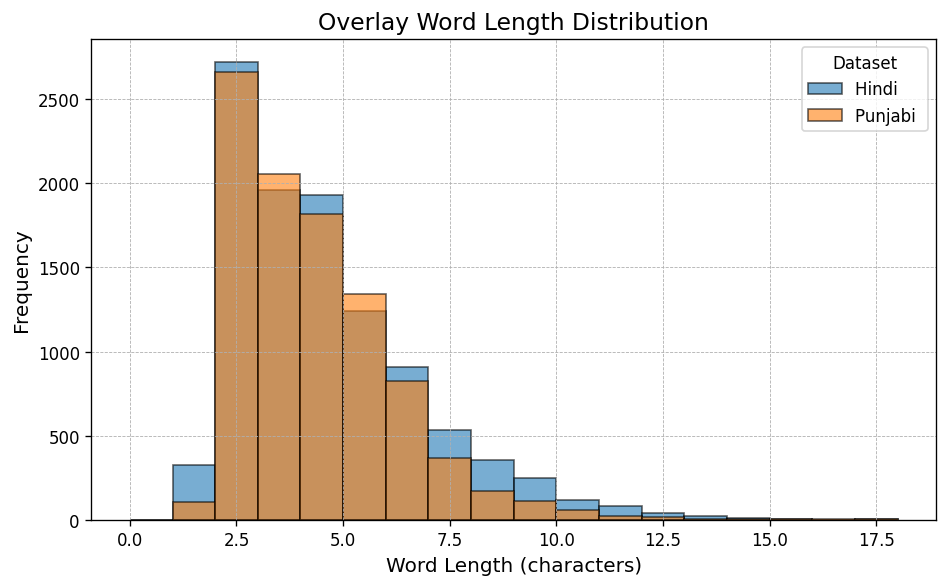

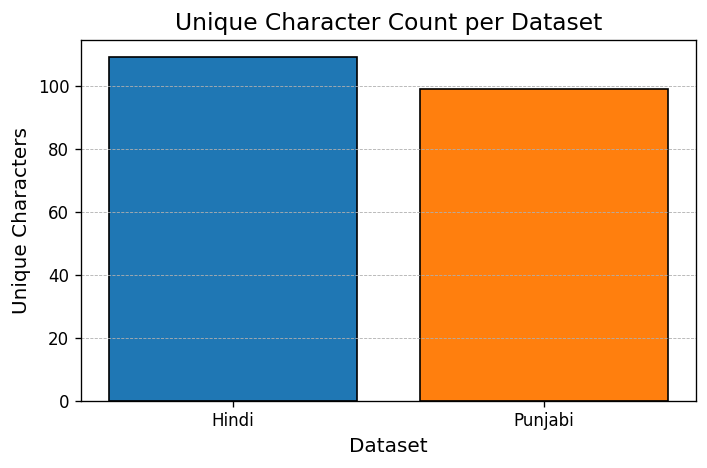

In [1]:
import sys
import csv
import matplotlib.pyplot as plt


def process_file(input_file):
    """
    Read a single annotation file and compute statistics:
      - word_lengths: list of all word lengths
      - unique_char_count: total unique characters across all images
    """
    word_lengths = []
    all_chars = set()

    with open(input_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t', 1)
            if len(parts) < 2:
                continue
            _, text = parts
            words = text.split()
            for w in words:
                word_lengths.append(len(w))
            all_chars.update(text)

    return word_lengths, len(all_chars)


def main(input_files):
    # Expect exactly 3 files
    if len(input_files) != 2:
        print("Usage: python ocr_stats.py <file1.txt> <file2.txt> <file3.txt>")
        sys.exit(1)

    datasets = []  # list of tuples (label, word_lengths, unique_count)
    languages = ["Hindi", "Punjabi"]
    for path, language in zip(input_files,languages):
        wl, uc = process_file(path)
        label = language#path.split('/')[-1].rsplit('.', 1)[0]
        datasets.append((label, wl, uc))

    # Choose a vibrant color palette
    colors = plt.cm.tab10.colors  # 10 vibrant colors

    # Overlay histogram for word length distributions
    plt.figure(figsize=(8, 5), dpi=120)
    max_len = max((max(wl) if wl else 0) for _, wl, _ in datasets)
    bins = range(0, max_len + 2)
    for idx, (label, wl, _) in enumerate(datasets):
        plt.hist(wl,
                 bins=bins,
                 alpha=0.6,
                 edgecolor='black',
                 color=colors[idx % len(colors)],
                 label=f"{label} ")#(n={len(wl)})

    plt.title('Overlay Word Length Distribution', fontsize=14)
    plt.xlabel('Word Length (characters)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend(title='Dataset', fontsize=10)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.savefig('overlay_word_length_distribution.png')

    # Bar plot of unique character counts
    labels = [label for label, _, _ in datasets]
    counts = [uc for _, _, uc in datasets]
    plt.figure(figsize=(6, 4), dpi=120)
    bar_colors = [colors[i % len(colors)] for i in range(len(labels))]
    plt.bar(labels, counts, color=bar_colors, edgecolor='black')
    plt.title('Unique Character Count per Dataset', fontsize=14)
    plt.xlabel('Dataset', fontsize=12)
    plt.ylabel('Unique Characters', fontsize=12)
    plt.grid(axis='y', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.savefig('unique_char_count_comparison.png')

    print("Generated:")
    print(" - overlay_word_length_distribution.png")
    print(" - unique_char_count_comparison.png")


if __name__ == "__main__":
    # if len(sys.argv) != 4:
    #     print("Usage: python ocr_stats.py <file1.txt> <file2.txt> <file3.txt>")
    #     sys.exit(1)
    main([main(["/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/train_holdeout_images_labels/train_merged.txt", "/home/akash/ws/limited_supervision_ocr/data_pb/pb_word_images/train/train_labels.txt"])])


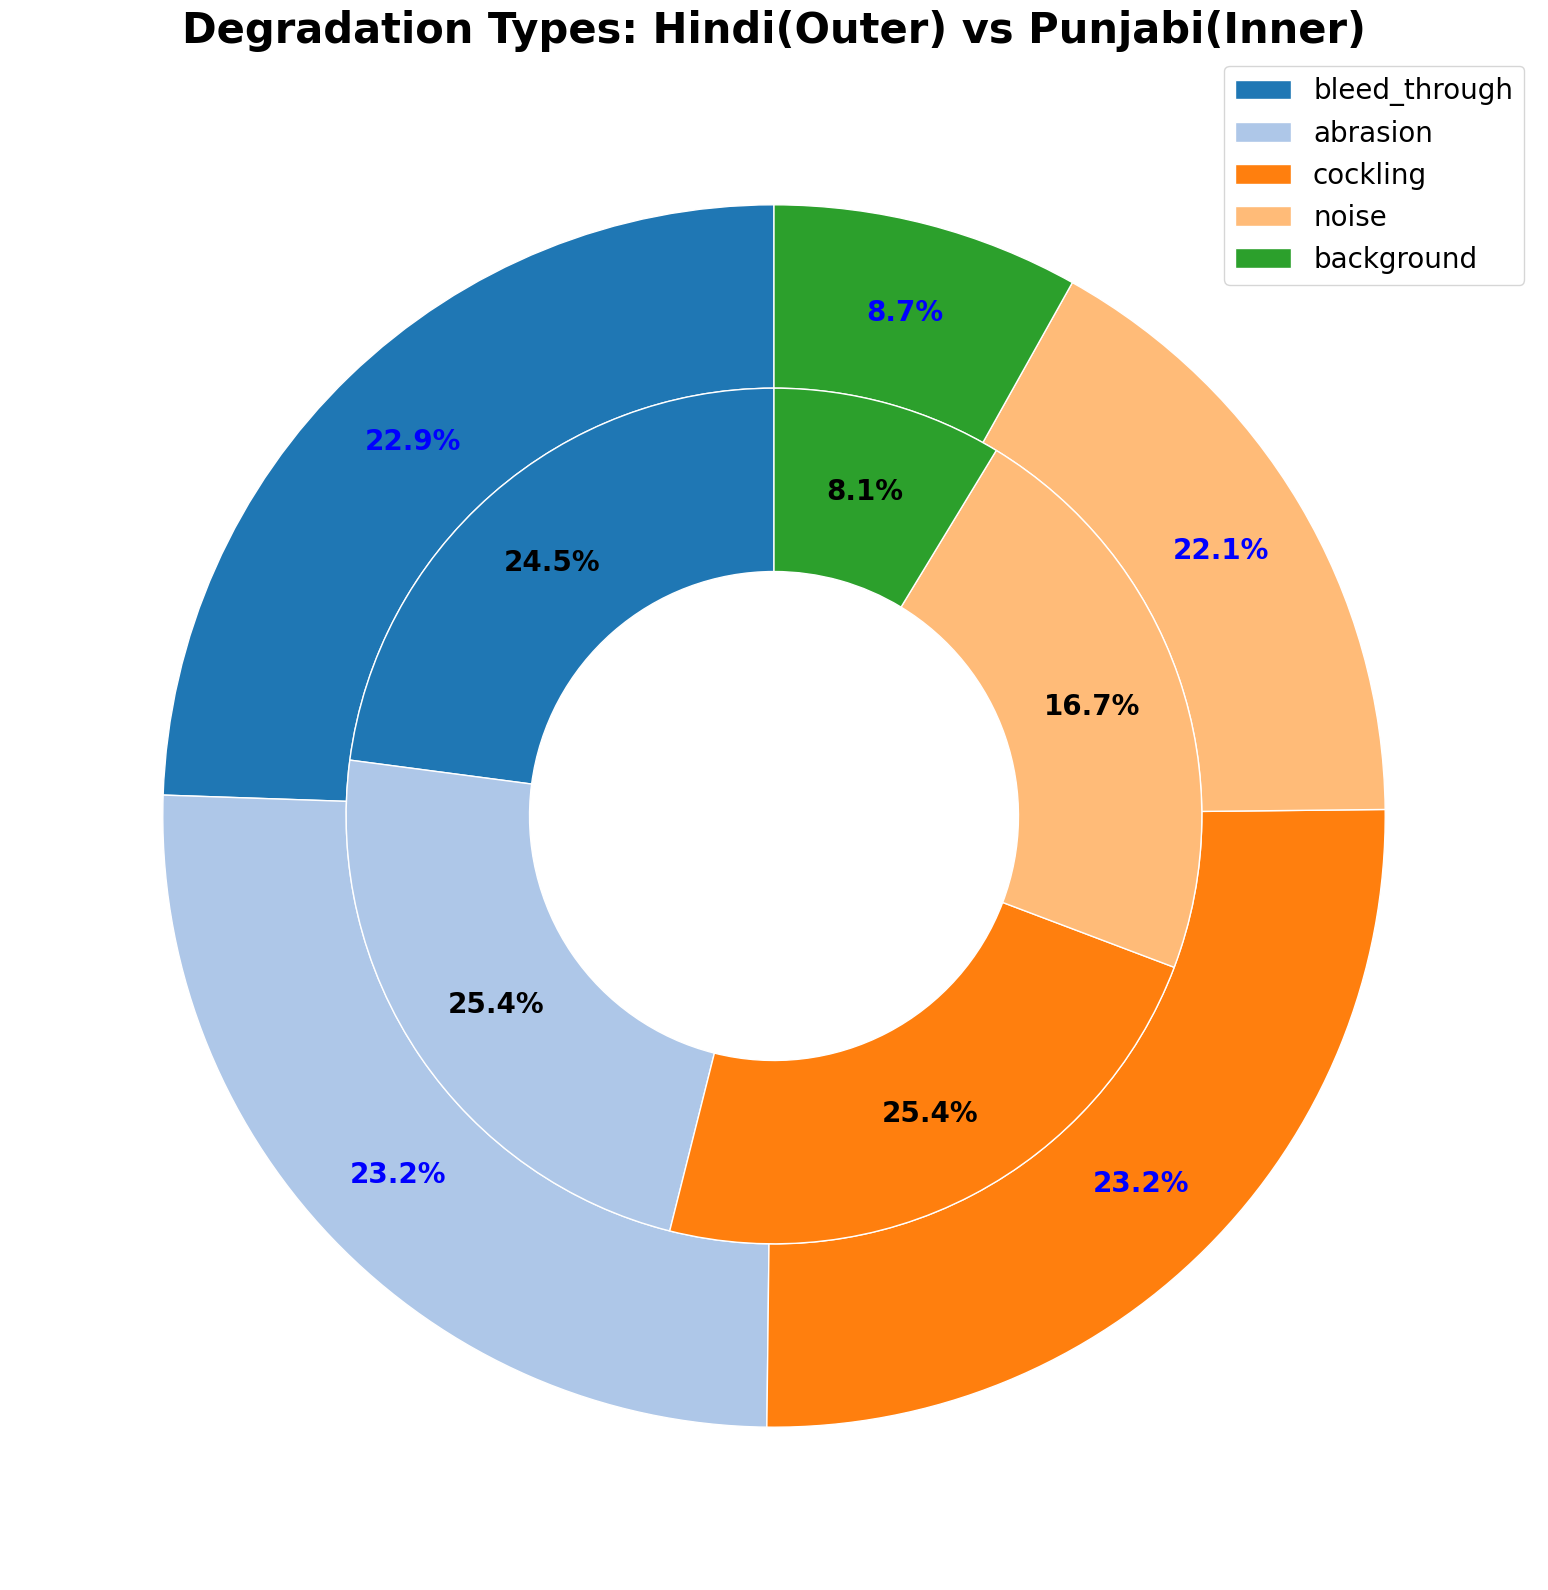

In [37]:
import sys
import csv
import cv2
import numpy as np
from skimage import filters, color, morphology
import matplotlib.pyplot as plt


def parse_annotations(txt_path):
    """
    Parse a text file where each line contains: image_name<TAB>ocr_text
    Returns a dict mapping image names to their OCR text.
    """
    annots = {}
    with open(txt_path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            parts = line.strip().split('\t', 1)
            if len(parts) != 2:
                continue
            annots[parts[0]] = parts[1]
    return annots

# -------- Degradation Detection Functions --------

def detect_fading(image, threshold=100.0):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    var = cv2.Laplacian(gray, cv2.CV_64F).var()
    faded = var < threshold
    return var, faded


def detect_dislocation(image,
                       rho=1,
                       theta=np.pi/180,
                       thresh=100,
                       min_line_len=100,
                       max_line_gap=10):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    lines = cv2.HoughLinesP(edges, rho, theta, thresh,
                            minLineLength=min_line_len,
                            maxLineGap=max_line_gap)
    deviations = []
    if lines is not None:
        for x1, y1, x2, y2 in lines[:,0]:
            angle = abs(np.degrees(np.arctan2((y2-y1), (x2-x1))))
            dev = min(angle, 180 - angle)
            deviations.append(dev)
    avg_dev = float(np.mean(deviations)) if deviations else 0.0
    return avg_dev, len(deviations)


def detect_bleed_through(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    high = cv2.subtract(gray, blur)
    thresh = filters.threshold_otsu(high)
    mask = high > thresh
    return float(np.mean(mask))


def detect_foxing(image):
    """
    Detect reddish-brown spots via LAB a-channel threshold.
    Returns coverage ratio of foxing.
    """
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    a = lab[:,:,1]
    # foxing spots are high a-values
    thresh = np.percentile(a, 95)
    mask = a > thresh
    return np.mean(mask)


def detect_abrasion(image):
    """
    Detect scraped regions by low edge density in text areas.
    Returns float: percent of area with missing edges.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    # low-edge regions
    mask = edges == 0
    return np.mean(mask)


def detect_cockling(image):
    """
    Identify wrinkling via local curvature of intensity.
    Returns float: variance of Laplacian indicating surface distortions.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lap = cv2.Laplacian(gray, cv2.CV_64F)
    return np.var(lap)


def detect_blur(image):
    """
    Blur level: inverse of variance of Laplacian.
    Higher variance = sharper; return 1/var to indicate blur.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    var = cv2.Laplacian(gray, cv2.CV_64F).var()
    return 1.0 / (var + 1e-6)


def detect_noise(image):
    """
    Estimate noise energy via high-pass variance.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (3,3), 0)
    noise = (gray.astype(float) - blur.astype(float))**2
    return float(np.mean(noise))


def detect_watermark(image):
    """
    Rough detection by looking for semi-transparent logos:
    Find low-contrast overlay patterns.
    Returns float: percent of low-Sobel-gradient areas.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    sob = np.hypot(*np.gradient(gray.astype(float)))
    mask = sob < np.percentile(sob, 10)
    return np.mean(mask)


def detect_background_noise(image):
    """
    Measure inhomogeneity via standard deviation of local mean.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    means = cv2.blur(gray, (50,50))
    return float(np.std(means))


def detect_encoding_corruption(text):
    """
    Check OCR text for replacement� characters or garbled sequences.
    Returns count of unusual codepoints.
    """
    return sum(1 for c in text if ord(c) == 0xfffd)


def detect_file_damage(path):
    """
    Attempt to load image; return True if errors encountered.
    """
    try:
        _ = cv2.imread(path)
        return False
    except Exception:
        return True

# -------- Processing Pipeline --------
THRESHOLDS = {
    'fading_variance': 150.0,      # below => faded
    'dislocation_avg_deg': 5.0,    # above => dislocated
    'bleed_through': 0.05,
    'foxing': 0.05,
    'abrasion': 0.5,
    'cockling': 100.0,
    'blur': 0.02,
    'noise': 500.0,
    'watermark': 0.1,
    'background': 15.0,
    'encoding_corruption': 1,
}


def analyze_dataset(txt_path, fading_th=100.0):
    """
    Reads annotation file (image_path & OCR text per line),
    returns dict of stats per image.
    """
    annots = parse_annotations(txt_path)
    results = {}
    for img_path, text in annots.items():
        stats = {}
        try:
            img = cv2.imread(img_path)
            # Fading
            var, faded = detect_fading(img, threshold=fading_th)
            stats['fading_variance'] = var
            stats['fading_detected'] = faded
            # Dislocation
            ang, count = detect_dislocation(img)
            stats['dislocation_avg_deg'] = ang
            stats['dislocation_line_count'] = count
            # Bleed-through
            stats['bleed_through'] = detect_bleed_through(img)
            stats['foxing']        = detect_foxing(img)
            stats['abrasion']      = detect_abrasion(img)
            stats['cockling']      = detect_cockling(img)
            stats['blur']          = detect_blur(img)
            stats['noise']         = detect_noise(img)
            stats['watermark']     = detect_watermark(img)
            stats['background']    = detect_background_noise(img)
            stats['file_damage']   = detect_file_damage(img_path)
        except Exception as e:
            stats['error'] = str(e)
        stats['encoding_corruption'] = detect_encoding_corruption(text)
        results[img_path] = stats
    return results
def compute_counts(results, thresholds):
    """
    Given stats per image and thresholds, count how many images show each degradation.
    Returns dict: category -> count.
    """
    counts = {key: 0 for key in thresholds}
    for stats in results.values():
        for key, thresh in thresholds.items():
            val = stats.get(key, 0)
            if key == 'fading_variance':
                if val < thresh:
                    counts[key] += 1
            else:
                if val > thresh:
                    counts[key] += 1
    return counts
def plot_comparison_pies(counts1, counts2, labels, title1, title2):
    """
    Plot side-by-side pie charts for two count dicts.
    """
    sizes1 = [counts1[label] for label in labels]
    sizes2 = [counts2[label] for label in labels]
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].pie(sizes1, labels=labels, autopct='%1.1f%%', startangle=140)
    axes[0].set_title(title1)
    axes[0].axis('equal')
    axes[1].pie(sizes2, labels=labels, autopct='%1.1f%%', startangle=140)
    axes[1].set_title(title2)
    axes[1].axis('equal')
    plt.tight_layout()
    plt.show()

def plot_overlayed_pies(counts1, counts2, labels, title_outer, title_inner):
    """
    Overlay two donut charts (concentric pie charts) for two count dictionaries.
    • Uses a consistent color scheme for both rings.
    • Filters out categories where both datasets have a count of 0.
    • Displays only the numeric counts inside each wedge.
    • Adds a legend for each degradation type with its outer and inner numbers.
    """
    import numpy as np
    from matplotlib.patches import Patch

    # Compute total counts for each dataset over all labels.
    total_outer = sum(counts1.get(lab, 0) for lab in labels)
    total_inner = sum(counts2.get(lab, 0) for lab in labels)

    # Filter out classes with zero count in both datasets or less than 1% in both.
    new_labels, new_sizes1, new_sizes2 = [], [], []
    for lab in labels:
        s1 = counts1.get(lab, 0)
        s2 = counts2.get(lab, 0)
        # Skip if both counts are zero.
        if s1 == 0 and s2 == 0:
            continue
        # Compute percentage for each.
        pct1 = (s1 / total_outer * 100) if total_outer > 1 else 0
        pct2 = (s2 / total_inner * 100) if total_inner > 1 else 0
        # Filter out if both percentages are less than 1%
        if pct1 < 1 and pct2 < 1:
            continue
        new_labels.append(lab)
        new_sizes1.append(s1)
        new_sizes2.append(s2)

    if not new_labels:
        print("No degradation types to plot (all below 1%).")
        return

    # Use one consistent colormap.
    cmap = plt.get_cmap('tab20')
    colors = [cmap(i) for i in range(len(new_labels))]

    # Create figure
    fig, ax = plt.subplots(figsize=(16, 16))

    # Outer ring
    outer_wedges, outer_autotexts, _ = ax.pie(
        new_sizes1,
        radius=1,
        colors=colors,
        labels=None,
        autopct=lambda pct: "",  # disable default autopct text
        pctdistance=0.5,
        wedgeprops=dict(width=0.3, edgecolor='white'),
        startangle=90,
        textprops={'fontsize':14, 'fontweight':'bold', 'color':'white'}
    )

    # Inner ring
    inner_wedges, inner_autotexts, _ = ax.pie(
        new_sizes2,
        radius=0.7,
        colors=colors,
        labels=None,
        autopct=lambda pct: "",  # disable default autopct text
        pctdistance=0.4,
        wedgeprops=dict(width=0.3, edgecolor='white'),
        startangle=90,
        textprops={'fontsize':14, 'fontweight':'bold', 'color':'white'}
    )

    # Manually annotate each wedge with the raw numbers.
    # For outer ring:
    for i, wedge in enumerate(outer_wedges):
        angle = (wedge.theta2 + wedge.theta1) / 2.0
        # Position slightly outward from the center of the outer ring
        x = 0.85 * np.cos(np.deg2rad(angle))
        y = 0.85 * np.sin(np.deg2rad(angle))
        pct_inner = new_sizes2[i] / sum(new_sizes2) * 100
        ax.text(
            x, y, f"{pct_inner:.1f}%",
            ha='center', va='center',
            fontsize=20, fontweight='bold', color='blue'
        )

    # For inner ring:
    for i, wedge in enumerate(inner_wedges):
        angle = (wedge.theta2 + wedge.theta1) / 2.0
        x = 0.55 * np.cos(np.deg2rad(angle))
        y = 0.55 * np.sin(np.deg2rad(angle))
        pct_outer = new_sizes1[i] / sum(new_sizes1) * 100
        ax.text(
            x, y, f"{pct_outer:.1f}%",
            ha='center', va='center',
            fontsize=20, fontweight='bold', color='black'
        )

    ax.set(aspect="equal")
    plt.title(f"Degradation Types: Hindi(Outer) vs Punjabi(Inner)", fontsize=30, fontweight='bold')

    # Create legend entries for each degradation type.
    legend_elements = []
    for lab, s1, s2, col in zip(new_labels, new_sizes1, new_sizes2, colors):
        legend_elements.append(Patch(facecolor=col, edgecolor='white',
                                     label=f"{lab}")) #(Outer: {s1}, Inner: {s2})
    ax.legend(handles=legend_elements, loc='upper right', fontsize=20)

    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == '__main__':

    if len(sys.argv) != 2:
        print(f"Usage: python {sys.argv[0]} <labels1.txt> <labels2.txt>")
        sys.exit(1)
    txt1, txt2 = "/home/akash/ws/limited_supervision_ocr/data_hi/loksabha_1960s/train_holdeout_images_labels/train_merged.txt", "/home/akash/ws/limited_supervision_ocr/data_pb/pb_word_images/train/train_labels.txt"

    # Analyze both datasets
    res1 = analyze_dataset(txt1, fading_th=THRESHOLDS['fading_variance'])
    res2 = analyze_dataset(txt2, fading_th=THRESHOLDS['fading_variance'])

    # Compute counts
    counts1 = compute_counts(res1, THRESHOLDS)
    counts2 = compute_counts(res2, THRESHOLDS)

    # Common labels order
    categories = list(THRESHOLDS.keys())

    # Plot comparison
    plot_overlayed_pies(
        counts1, counts2,
        categories,
        title_outer=f"Degradations in '{txt1}'",
        title_inner=f"Degradations in '{txt2}'"
    )

